# TDGL NbSe$_2$ | CGT heterostructure Simulation

Simulation of NbSe₂|CGT bi/tri-layer superconductor under applied current and magnetic field, 
taking into account the magnetization of CGT.

Documentation: See README.md for physics, validity conditions, and theory.

Quick Start:
1. Edit paramters.py to model other materials or alter quality/runtime trade-off
2. Choose save method (manual or built-in)
3. Run full script
4. Results saved to results.h5

References:
- pyTDGL: https://py-tdgl.readthedocs.io/
- Van-Horn, L.B. (2023) "pyTDGL: Time-dependent Ginzburg-Landau in Python"


In [1]:
# ============================================================================
# Imports
# ============================================================================

import numpy as np

# Numpy compatibility patch
if int(np.__version__.split('.')[0]) < 2:
    np.trapezoid = np.trapz

import tdgl
import os
import h5py
import matplotlib.pyplot as plt
from tdgl.geometry import box, circle
from tdgl.visualization.animate import create_animation
import math
import time

try:
    import cupyx.jit
    import cupy as cp
    GPU_AVAILABLE=True
except ImportError:
    GPU_AVAILABLE=False

import parameters as params # Load the parameters
import io_functions as io # Load the helper functions

# ============================================================================
# Select save method
# ============================================================================

if params.SAVE_METHOD == "manual":
    save_all_sol = io.save_all_sol_manual
elif params.SAVE_METHOD == "builtin":
    save_all_sol = io.save_all_sol_builtin
else:
    raise ValueError(f"Unknown save method: {params.SAVE_METHOD}")

# ============================================================================
os.environ["OPENBLAS_NUM_THREADS"] = "1"
plt.rcParams["figure.figsize"] = (5, 4)

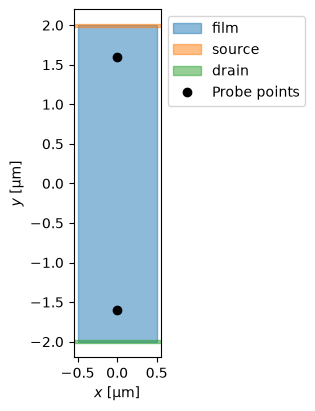

In [2]:
#============================================================================================================
# Device Setup
#============================================================================================================

layer = tdgl.Layer(
    coherence_length = params.XI,
    london_lambda = params.LONDON_LAMBDA,
    thickness = params.THICKNESS,
    gamma = params.GAMMA,
    conductivity = params.SIGMA,
)

# Device geometry

film = (
    tdgl.Polygon("film", points=box(params.WIDTH, params.LENGTH))
)

# Current terminals
source = (
    tdgl.Polygon("source", points=box(1.1 * params.WIDTH, params.LENGTH / 100))
    .translate(dy= params.LENGTH / 2)
)
drain = source.scale(yfact=-1).set_name("drain")
#  Voltage measurement points
probe_points = [(0, params.LENGTH / 2.5), (0, -params.LENGTH / 2.5)]

device = tdgl.Device(
    "device",
    layer = layer,
    film = film,
    terminals = [source, drain],
    probe_points = probe_points,
    length_units = params.LENGTH_UNITS,
)

fig, ax = device.draw()

In [3]:
#============================================================================================================
# Initialize the mesh
#============================================================================================================

device.make_mesh(max_edge_length = params.MAX_EDGE_LENGTH, smooth=100)

Constructing Voronoi polygons:   0%|          | 0/25848 [00:00<?, ?it/s]Malformed Voronoi cell surrounding boundary site 1. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 3. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 4. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Constructing Voronoi polygons:   0%|          | 8/25848 [00:00<05:47, 74.43it/s]Malformed Voronoi cell surrounding boundary site 13. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 21. Try changing the number of boundary me

In [4]:
device.mesh_stats()

num_sites,25848
num_elements,50960
min_edge_length,5.787e-03
max_edge_length,2.564e-02
mean_edge_length,1.351e-02
min_area,3.717e-05
max_area,3.191e-04
mean_area,1.548e-04
coherence_length,5.370e-02
length_units,um


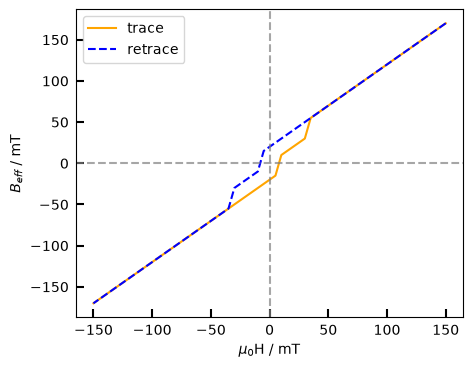

In [5]:
#-----------------------------------------------------------
# Define magnetic field applied and CGT magnetization offset
#-----------------------------------------------------------

B_up = np.linspace(params.LOW_B,params.HIGH_B, params.RUNS)
B_down = B_up[::-1]

if params.MODEL == "bare":
    B_up_tot = B_up
    B_down_tot = B_down
elif params.MODEL == "bilayer":
    B_up_tot = np.where(B_up < params.BI_THRESH, B_up - params.BI_CGT_MAG, B_up + params.BI_CGT_MAG)
    B_down_tot = np.where(B_down > params.BI_THRESH2, B_down + params.BI_CGT_MAG, B_down - params.BI_CGT_MAG)
elif params.MODEL == "trilayer":
    H_coerc_up = [
     B_up < params.TRI_THRESH_L,
     (params.TRI_THRESH_L <= B_up) & (B_up <= params.TRI_THRESH_U),
     params.TRI_THRESH_U < B_up 
    ]
    H_coerc_down = [
    B_down > params.TRI_THRESH_L2,
    (params.TRI_THRESH_U2 <= B_down) & (B_down <= params.TRI_THRESH_L2),
    params.TRI_THRESH_U2 > B_down 
    ]
    cgt_mag_up = [
        -params.TRI_CGT_MAG,  # Parallel state (both magnets pointing down)
        0,    # Anti-Parallel state (magnets cancel out)
        +params.TRI_CGT_MAG   # Parallel state (both magnets pointing up) 
    ]
    cgt_mag_down = [
        +params.TRI_CGT_MAG,  # Parallel state (both magnets pointing up)
        0,    # Anti-Parallel state (magnets cancel out)
        -params.TRI_CGT_MAG   # Parallel state (both magnets pointing down)
    ]     
    cgt_contr_up = np.select(H_coerc_up, cgt_mag_up, default=0)
    cgt_contr_down = np.select(H_coerc_down, cgt_mag_down, default=0)
    B_up_tot = B_up + cgt_contr_up
    B_down_tot = B_down + cgt_contr_down
else:
    raise ValueError(f"Unknown model: {params.MODEL}")
    
#--------------------------------------
# Plot magnetic field applied to device
#--------------------------------------

plt.plot(B_up,B_up_tot, c = "orange", label="trace")
plt.plot(B_down,B_down_tot, "--", c = "blue", label="retrace")

plt.xlabel("$\mu_0$H / mT")
plt.ylabel("$B_{eff}$ / mT")

plt.axvline(x = 0, color = 'grey',ls='--', alpha = 0.7)
plt.axhline(y = 0, color = 'grey',ls='--', alpha = 0.7)

plt.legend()

plt.gca().set_facecolor('white')
plt.tick_params(
    direction='in',     
    length=6,            
    width=1.5,           
    pad=5                
)

In [ ]:
#----------------------
# Main Simulation Block
#----------------------
sim_start_time = time.time()
I_values = np.linspace(params.I_LOW, params.I_HIGH, params.NUM_CURRENTS)
I_times = {}

all_sol = {} #storage for everything (outer nested dictionary)
all_sol['mesh'] = None

options = tdgl.SolverOptions(
    solve_time = params.SOLVE_TIME,
    skip_time = params.SKIP_TIME,
    output_file = None,
    field_units = params.FIELD_UNITS,
    current_units = params.CURRENT_UNITS,
    gpu=GPU_AVAILABLE, 
)

for I in I_values:
    print(f"Looping over I = {I} uA")
    I_start = time.time()
    all_sol[I] = {'up': {}, 'down': {}} # Make inner nested dictionaries

    print(f"Running up sweep for I = {I} uA")
    seed = None # Initiates the seed
    for i, B in enumerate(B_up):
        solution = tdgl.solve(
            device,
            options,
            applied_vector_potential=B_up_tot[i],
            terminal_currents=dict(source=I, drain=-I),
            seed_solution=seed,
        )

        # Store full solution in the memory
        all_sol[I]['up'][B] = solution
    
        seed = solution  # Use this solution as seed for next iteration

        # Extract and cache mesh on first iteration
        if i == 0 and I == I_values[0]:
            mesh_data = extract_and_cache_mesh(solution)
            all_sol['mesh'] = mesh_data
            print(f"Mesh extracted and stored: {mesh_data['coordinates'].shape} nodes")
   
        print(f"I={I} uA: Run {i+1} of {Runs} completed (up sweep)")

    
    print(f"up sweep complete for I = {I} uA")

    # Down Sweep

    print(f"Running down sweep for I = {I} uA")
    
    for k, B in enumerate(B_down):
        solution = tdgl.solve(
            device,
            options,
            applied_vector_potential=B_down_tot[k],
            terminal_currents=dict(source=I, drain=-I),
            seed_solution=seed,
        )

        all_sol[I]['down'][B] = solution
        
        seed = solution 
        
        print(f"I={I} uA: Run {k+1} out of {Runs} completed (down sweep)")

    print(f"down sweep complete for I = {I} uA")
    I_end = time.time()
    I_time_tot = (I_end - I_start)/3600
    I_times[I] = I_time_tot

print("All Current sweeps completed")
print(f"\nMesh data stored: {all_sol['mesh'] is not None}")

sim_end_time = time.time()

V_0_dev = device.V0() #value for V_0 extracted from the device - needed to scale the y-axis to Ohms when plotting

Looping over I = 1.0 uA
Running up sweep for I = 1.0 uA


Thermalizing:   7%|▋         | 4/50 [01:47<07:16,  9.41s/tau ]       

In [ ]:
#-------------------
# Simulation Runtime
#-------------------

sim_time = (sim_end_time - sim_start_time)/3600
print("Total simulation time =", f"{sim_time:.1f}", "hrs")

for I in I_times.keys():
    print(f"Time taken for {I} sweep", f"{I_times[I]:.1f}", "hrs")

In [ ]:
# ============================================================================
# SAVE all_sol TO HDF5 FILE
# ============================================================================

print("\n" + "="*70)
print("SAVING SIMULATION DATA TO HDF5 FILE")
print("="*70 + "\n")

filename = 'Simulation_Results.h5'
save_all_sol(all_sol, I_values, filename)

# Add V_0_dev to the H5 file
with h5py.File(filename, 'a') as f:
    f['metadata'].attrs['V_0_dev'] = V_0_dev

In [ ]:
tdgl.version_table()